In [0]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from contract_dates_functions import *

from volatility_functions import *

from option_pricing_functions import *

from implied_cnh_rate_functions import *

# sys.path.append('/Workspace/Users/leigh.murray@futurefund.gov.au/FX Option Backtester/Backtesting')
# from valuation_functions import *

## 1. Data Set Up

In [0]:
# contract dates
contracts_df = pd.read_csv(
    'contract_dates.csv',
    parse_dates=['Start_Date', 'Settlement_Date', 'Expiry_Date', 'Delivery_Date', 'Exit_Date'],
    )  # Dates in YYYY-MM-DD

# forward data
forward_df = pd.read_csv('', 
                         index_col=0, 
                         parse_dates=[0],
                         dayfirst=True,
                         na_values=['#N/A Weekend pricing date', 
                                   '#N/A Holiday', 
                                   '#N/A Weekend',
                                   '#N/A CorrelationId not found: [ valueType=INT classId=0 internalClassId=0 value=1060111 ]'],
                         keep_default_na=True)

# interpolated SOFR 
sofr_df = pd.read_parquet('')

# spot price data
spot_df = pd.read_csv('',
                      index_col=0,
                      parse_dates=[0],
                      dayfirst=True,
                      names=['Date', 'Spot'],  # Add column names
                      na_values=['#N/A N/A'])

# interpolated volatility
vol_bsplines_df = pd.read_parquet('volatility_bsplines_5.parquet')
vol_bsplines_df['date'] = pd.to_datetime(vol_bsplines_df['date'])

vol_date_tenor_df = pd.read_parquet('volatility_date_tenor_days.parquet')
vol_date_tenor_df['date'] = pd.to_datetime(vol_date_tenor_df['date'])

# non settlement dates
fed_holidays = set(
    pd.to_datetime(
        pd.read_csv('').iloc[:, 0], 
        dayfirst=True
    )
)

cnh_holidays = set(
    pd.to_datetime(
        pd.read_csv('').iloc[:, 0], 
        dayfirst=True
    )
)

# Set pricing dates (the dates with data available)

pricing_dates = sofr_df.index.get_level_values('Pricing Date').unique()

Optional: Select pricing dates based on data available, check exit dates are able to be priced, practice how to call data

In [0]:
# OPTIONAL: figuring out dates

# available pricing / valuing / trading dates (but may have NaN values in them)
vol_dates = pd.DatetimeIndex(vol_bsplines_df['date'].unique())
forward_dates = forward_df.index.unique()
sofr_dates = sofr_df.index.get_level_values('Pricing Date').unique()
spot_dates = spot_df.index.unique()

# Check if all dates are identical
all_same = (
    set(forward_dates) == set(sofr_dates) == set(spot_dates) 
    == set(vol_dates)
)

print(f"Forward dates: {len(forward_dates)} ({forward_dates.min()} to {forward_dates.max()})")
print(f"SOFR dates: {len(sofr_dates)} ({sofr_dates.min()} to {sofr_dates.max()})")
print(f"Spot dates: {len(spot_dates)} ({spot_dates.min()} to {spot_dates.max()})")
print(f"Vol dates: {len(vol_dates)} ({vol_dates.min()} to {vol_dates.max()})")
print(f"\nAll datasets have same dates: {all_same}")

date_sets = {
    'Forward': set(forward_dates),
    'SOFR': set(sofr_dates),
    'Spot': set(spot_dates),
    'Vol': set(vol_dates)
}

for name, dates in date_sets.items():
    matches = [other for other, other_dates in date_sets.items() 
               if other != name and dates == other_dates]
    match_str = ', '.join(matches) if matches else 'None'
    print(f"{name}: {len(dates)} dates | Matches: {match_str}")

missing_in_sofr = set(vol_dates) - set(sofr_dates)
print(f"\nDates in Vol but not in SOFR: {len(missing_in_sofr)}")

# Check how many are Fed holidays
missing_fed_holidays = missing_in_sofr & fed_holidays
print(f"Of these, {len(missing_fed_holidays)} are Fed holidays")

# Print all missing dates
for date in sorted(missing_in_sofr):
    is_fed_holiday = "FED HOLIDAY" if date in fed_holidays else ""
    print(f"{date} {is_fed_holiday}")

print(f"\n 2025-04-18 was good friday (SOFR follows calendar US not FED)")

print(f"\n Choose pricing dates to be SOFR dates, so that there is data at every pricing point")

pricing_dates = sofr_dates

Forward dates: 1832 (2021-04-09 00:00:00 to 2026-04-14 00:00:00)
SOFR dates: 1300 (2021-04-09 00:00:00 to 2026-04-14 00:00:00)
Spot dates: 1832 (2021-04-09 00:00:00 to 2026-04-14 00:00:00)
Vol dates: 1308 (2021-04-09 00:00:00 to 2026-04-14 00:00:00)

All datasets have same dates: False
Forward: 1832 dates | Matches: Spot
SOFR: 1300 dates | Matches: None
Spot: 1832 dates | Matches: Forward
Vol: 1308 dates | Matches: None

Dates in Vol but not in SOFR: 8
Of these, 7 are Fed holidays
2023-10-09 00:00:00 FED HOLIDAY
2023-12-25 00:00:00 FED HOLIDAY
2024-01-01 00:00:00 FED HOLIDAY
2024-12-25 00:00:00 FED HOLIDAY
2025-01-01 00:00:00 FED HOLIDAY
2025-04-18 00:00:00 
2025-12-25 00:00:00 FED HOLIDAY
2026-01-01 00:00:00 FED HOLIDAY

 2025-04-18 was good friday (SOFR follows calendar US not FED)

 Choose pricing dates to be SOFR dates, so that there is data at every pricing point


In [0]:
# Check if any Exit_Dates or Start_Dates are not in pricing_dates
missing_exit_dates = set(contracts_df['Exit_Date'].dropna()) - set(pricing_dates)

print(f"Exit dates not in pricing_dates: {len(missing_exit_dates)}")
if missing_exit_dates:
    for date in sorted(missing_exit_dates):
        print(f"  {date}")

for exit_date in contracts_df['Start_Date'].dropna():
    if exit_date not in pricing_dates:
        print(f"{start_date} not in pricing_dates")

In [0]:
# HOW TO CALL DATA

# choose a pricing/trading date between 2021-04-09 and 2026-04-14 that is not a weekend day
trading_date_prac = pd.to_datetime('2025-07-15')

# choose a tenor (up to 1Y) in format '1W','3M','1Y','90D','90', or 90
practice_tenor = '3M' 

# get standard contract dates
settlement_date_prac, expiry_date_prac, delivery_date_prac = get_contract_dates(trading_date_prac, practice_tenor) # note: forward contract doesn't actually have expiry date

# get days required
trade_to_expiry_days_prac = (expiry_date_prac - trading_date_prac).days # for pricing
settlement_to_delivery_days_prac = (delivery_date_prac - settlement_date_prac).days # for pricing
trade_to_delivery_days_prac = (delivery_date_prac - trading_date_prac).days # for SOFR and forward

# these are valid for a forward or an option with the set trading date and tenor
forward = forward_df.loc[trading_date_prac][trade_to_delivery_days_prac-1]
foreign_interest_rate = sofr_df.loc[(trading_date_prac, expiry_date_prac), 'SOFR'] # uses trading / expiry but it is actually the rate until delivery date
spot = spot_df.loc[trading_date_prac, 'Spot']
implied_domestic_interest_rate = get_implied_cnh_rate(trading_date_prac, practice_tenor, forward_df, sofr_df, spot_df)
another_implied_domestic_interest_rate = get_implied_cnh_rate_no_tenor(trading_date_prac, settlement_date_prac, expiry_date_prac, delivery_date_prac, forward_df, sofr_df, spot_df)

# volatility example, side must be 'P' or 'C'

call_delta_given_prac = 0.25
put_delta_given_prac = 0.25

call_vol_interp = get_volatility_from_bsplines(trading_date_prac, trade_to_expiry_days_prac, 
                                                call_delta_given_prac, 'C', vol_bsplines_df, 
                                                vol_date_tenor_df)
put_vol_interp = get_volatility_from_bsplines(trading_date_prac, trade_to_expiry_days_prac, 
                                               put_delta_given_prac, 'P', vol_bsplines_df, 
                                               vol_date_tenor_df)

for var in ['trading_date_prac', 'spot', 'expiry_date_prac', 'delivery_date_prac', 
            'forward', 'foreign_interest_rate', 'implied_domestic_interest_rate', 'another_implied_domestic_interest_rate', 
            'settlement_date_prac', 'practice_tenor', 'domestic_day_count', 
            'foreign_day_count', 'trade_to_expiry_days_prac', 
            'settlement_to_delivery_days_prac', 'trade_to_delivery_days_prac',
            'call_delta_given_prac', 'put_delta_given_prac', 
            'call_vol_interp', 'put_vol_interp']:
    print(f"{var}: {eval(var)}")

## Fixing hedging functions

In [0]:
def price_forward_contracts_unit_notional(contracts_df,
                                          pricing_dates,
                                          spot_df,
                                          forward_df,
                                          sofr_df,
                                          notional: float = 1) -> pd.DataFrame:
    """
    Prices forward contracts across all pricing dates.
    
    Args:
        contracts_df: DataFrame with contract details
        pricing_dates: List of dates to price
        spot_df, forward_df, sofr_df: Market data dataframes
        notional: USD notional per contract (default=1)
    
    Returns:
        DataFrame with daily forward contract values
    """
    
    rows = []
    skipped_dates = []
    
    # Iterate through each contract
    for idx, contract in contracts_df.iterrows():
        contract_id = contract['Contract_ID']
        position = contract['Position']
        start_date = contract['Start_Date']
        settlement_date = contract['Settlement_Date']
        exit_date = contract['Exit_Date']
        expiry_date = contract['Expiry_Date']
        delivery_date = contract['Delivery_Date']

        contract_pricing_dates = [d for d in pricing_dates if start_date <= d <= exit_date]
        
        # Calculate contracted forward rate (at Start_Date)
        try:
            start_to_delivery_days = (delivery_date - start_date).days
            contracted_forward = forward_df.loc[start_date][start_to_delivery_days - 1]
            
            if pd.isna(contracted_forward):
                print(f"ERROR - Contracted Forward | Date: {start_date} | Days: {start_to_delivery_days} nan forward")
                skipped_dates.append((contract_id, start_date, 'contracted forward nan'))
                continue
        except Exception as e:
            print(f"ERROR - Contracted Forward | Date: {start_date} | Days: {start_to_delivery_days} | Error: {e}")
            skipped_dates.append((contract_id, start_date, 'contracted forward'))
            continue
        
        # Loop through each pricing date
        for pricing_date in contract_pricing_dates:
            pricing_to_delivery_days = (delivery_date - pricing_date).days
            pricing_settlement_date = get_T2_lag_date(pricing_date)
            pricing_settlement_to_delivery_days = (delivery_date - pricing_settlement_date).days
            time_discount_domestic = pricing_settlement_to_delivery_days / 360
            
            try:
                # Market forward rate
                market_forward = forward_df.loc[pricing_date][pricing_to_delivery_days - 1]
                if pd.isna(market_forward):
                    print(f"ERROR - Market Forward is NaN | Contract {contract_id} | Pricing Date: {pricing_date} | Days: {pricing_to_delivery_days}")
                    skipped_dates.append((contract_id, pricing_date, 'market forward'))
                    continue
            except Exception as e:
                print(f"ERROR - Market Forward | Pricing Date: {pricing_date} | Days: {pricing_to_delivery_days} | Error: {e}")
                skipped_dates.append((contract_id, pricing_date, 'market forward'))
                continue
            
            try:
                # Spot price
                spot = spot_df.loc[pricing_date, 'Spot']
                if pd.isna(spot):
                    print(f"ERROR - Spot is NaN | Contract {contract_id} | Pricing Date: {pricing_date}")
                    skipped_dates.append((contract_id, pricing_date, 'spot'))
                    continue
            except Exception as e:
                print(f"ERROR - Spot | Pricing Date: {pricing_date} | Error: {e}")
                skipped_dates.append((contract_id, pricing_date, 'spot'))
                continue
            
            try:
                # Implied domestic interest rate
                implied_domestic_interest_rate = get_implied_cnh_rate_no_tenor(
                    pricing_date, pricing_settlement_date, expiry_date, delivery_date, 
                    forward_df, sofr_df, spot_df
                )
                if pd.isna(implied_domestic_interest_rate) or np.isinf(implied_domestic_interest_rate):
                    print(f"ERROR - Implied Rate is NaN/inf | Contract {contract_id} | Pricing Date: {pricing_date}")
                    skipped_dates.append((contract_id, pricing_date, 'implied rate'))
                    continue
            except Exception as e:
                print(f"ERROR - Implied Rate {contract_id} | Pricing Date: {pricing_date} | Error: {e}")
                skipped_dates.append((contract_id, pricing_date, 'implied rate'))
                continue
            
            try:
                # Contract value calculation IN USD
                contract_value = ((1 / (1 + implied_domestic_interest_rate * time_discount_domestic) * 
                                  (market_forward - contracted_forward)) / spot) * notional
                if pd.isna(contract_value) or np.isinf(contract_value):
                    print(f"ERROR - Contract Value is NaN/inf | Contract {contract_id} | Pricing Date: {pricing_date}")
                    skipped_dates.append((contract_id, pricing_date, 'contract value'))
                    continue
            except Exception as e:
                print(f"ERROR - Contract Value | Pricing Date: {pricing_date} | Error: {e}")
                skipped_dates.append((contract_id, pricing_date, 'contract value'))
                continue
            
            # Append row
            rows.append({
                'Contract_ID': contract_id,
                'Position': position,
                'Pricing_Date': pricing_date,
                'Start_Date': start_date,
                'Settlement_Date': settlement_date,
                'Expiry_Date': expiry_date,
                'Delivery_Date': delivery_date,
                'Exit_Date': exit_date,
                'Contracted_Forward': contracted_forward,
                'Market_Forward': market_forward,
                'Value': contract_value,
                'Notional': notional,
                'Value (Notional)': contract_value * notional
            })

    # Create DataFrame
    forward_contracts_daily_values_df = pd.DataFrame(rows)
    print(f"Successfully created {len(rows)} rows")
    print(f"Skipped {len(skipped_dates)} date-contract combinations")

    return forward_contracts_daily_values_df

In [0]:
def price_risk_reversal_contracts_unit_notional(initiate_call_delta: float,
                                                    contracts_df,
                                                    pricing_dates,
                                                    spot_df,
                                                    forward_df,
                                                    sofr_df,
                                                    vol_bsplines_df,
                                                    vol_date_tenor_df,
                                                    notional_ccy: str = 'foreign',
                                                    premium_ccy: str = 'foreign',
                                                    notional: float = 1):
    """
    Prices risk reversal contracts across all pricing dates.
    
    Args:
        initiate_call_delta: Target call delta at inception (e.g., 0.25 for 25%)
        contracts_df: DataFrame with contract details
        pricing_dates: List of dates to price
        spot_df, forward_df, sofr_df: Market data dataframes
        vol_bsplines_df, vol_date_tenor_df: Volatility surface dataframes
        notional_ccy: Notional currency ('foreign' or 'domestic')
        premium_ccy: Premium currency ('foreign' or 'domestic')
        notional: USD notional per contract (default=1)
    
    Returns:
        DataFrame with daily risk reversal values
    """
    
    rows = []
    skipped_dates = []
    
    # Iterate through each contract
    for idx, contract in contracts_df.iterrows():
        contract_id = contract['Contract_ID']
        position = contract['Position']
        start_date = contract['Start_Date']
        settlement_date = contract['Settlement_Date']
        exit_date = contract['Exit_Date']
        expiry_date = contract['Expiry_Date']
        delivery_date = contract['Delivery_Date']
        
        contract_pricing_dates = [d for d in pricing_dates if start_date <= d <= exit_date]
        
        # Create risk reversal entry with validation
        try:
            rr_result = enter_risk_reversal_no_tenor(start_date, settlement_date, expiry_date, 
                                                        delivery_date, initiate_call_delta, 
                                                        spot_df, forward_df, sofr_df, 
                                                        vol_bsplines_df, vol_date_tenor_df,
                                                        notional_ccy, premium_ccy)
            
            call_strike = rr_result['call_strike']
            put_strike = rr_result['put_strike']
            
            # Validate strikes from RR entry
            if pd.isna(call_strike) or pd.isna(put_strike):
                print(f"ERROR - RR entry returned NaN strikes | Contract {contract_id} | Call: {call_strike} | Put: {put_strike}")
                skipped_dates.append((contract_id, start_date, 'rr strikes nan'))
                continue
                
            if call_strike <= 0 or put_strike <= 0:
                print(f"ERROR - RR entry returned invalid strikes | Contract {contract_id} | Call: {call_strike} | Put: {put_strike}")
                skipped_dates.append((contract_id, start_date, 'rr strikes invalid'))
                continue
                
        except Exception as e:
            print(f"ERROR - Risk reversal entry failed | Contract {contract_id} | Error: {e}")
            skipped_dates.append((contract_id, start_date, f'rr entry: {e}'))
            continue
        
        # Loop through each pricing date
        for pricing_date in contract_pricing_dates:
            
            pricing_to_delivery_days = (delivery_date - pricing_date).days
            pricing_settlement_date = get_T2_lag_date(pricing_date)
            pricing_settlement_to_delivery_days = (delivery_date - pricing_settlement_date).days
            pricing_to_expiry_days = (expiry_date - pricing_date).days
            
            # Get market data
            try:
                forward = forward_df.loc[pricing_date][pricing_to_delivery_days - 1]
                if pd.isna(forward) or forward <= 0:
                    print(f"ERROR - Invalid forward: {forward} | Contract {contract_id} | Date: {pricing_date}")
                    skipped_dates.append((contract_id, pricing_date, f'forward={forward}'))
                    continue
            except Exception as e:
                print(f"ERROR - Forward lookup | Contract {contract_id} | Date: {pricing_date} | Error: {e}")
                skipped_dates.append((contract_id, pricing_date, f'forward: {e}'))
                continue
            
            try:
                spot = spot_df.loc[pricing_date, 'Spot']
                if pd.isna(spot) or spot <= 0:
                    print(f"ERROR - Invalid spot: {spot} | Contract {contract_id} | Date: {pricing_date}")
                    skipped_dates.append((contract_id, pricing_date, f'spot={spot}'))
                    continue
            except Exception as e:
                print(f"ERROR - Spot lookup | Contract {contract_id} | Date: {pricing_date} | Error: {e}")
                skipped_dates.append((contract_id, pricing_date, f'spot: {e}'))
                continue
            
            try:
                foreign_interest_rate = sofr_df.loc[(pricing_date, expiry_date), 'SOFR']
                if pd.isna(foreign_interest_rate) or np.isinf(foreign_interest_rate):
                    print(f"ERROR - Invalid SOFR: {foreign_interest_rate} | Contract {contract_id} | Date: {pricing_date}")
                    skipped_dates.append((contract_id, pricing_date, f'SOFR={foreign_interest_rate}'))
                    continue
            except Exception as e:
                print(f"ERROR - SOFR lookup | Contract {contract_id} | Date: {pricing_date} | Error: {e}")
                skipped_dates.append((contract_id, pricing_date, f'SOFR: {e}'))
                continue
            
            # Price call option with validation
            try:
                call_vol_from_strike = strike_to_volatility(spot, pricing_date, pricing_settlement_date, expiry_date,
                                                            delivery_date, call_strike, foreign_interest_rate,
                                                            forward, 'C', vol_bsplines_df, vol_date_tenor_df)
                
                if pd.isna(call_vol_from_strike) or call_vol_from_strike <= 0 or call_vol_from_strike > 1:
                    print(f"ERROR - Invalid call vol: {call_vol_from_strike} | Contract {contract_id} | Date: {pricing_date}")
                    skipped_dates.append((contract_id, pricing_date, f'call_vol={call_vol_from_strike}'))
                    continue
                
                call_result = price_fx_option(spot, pricing_to_expiry_days, pricing_settlement_to_delivery_days,
                                            call_strike, foreign_interest_rate, forward, 
                                            call_vol_from_strike, 'C', notional_ccy, premium_ccy)
                
                call_premium = call_result[0]
                call_delta = call_result[4]
                call_volatility = call_vol_from_strike
                
                # Validate call pricing results
                if pd.isna(call_premium) or pd.isna(call_delta) or np.isinf(call_premium):
                    print(f"ERROR - Invalid call pricing | Contract {contract_id} | Date: {pricing_date}")
                    print(f"  Premium: {call_premium} | Delta: {call_delta}")
                    skipped_dates.append((contract_id, pricing_date, 'call_pricing_invalid'))
                    continue
                    
            except Exception as e:
                print(f"ERROR - Call pricing failed | Contract {contract_id} | Date: {pricing_date} | Error: {e}")
                skipped_dates.append((contract_id, pricing_date, f'call_pricing: {e}'))
                continue
            
            # Price put option with validation
            try:
                put_vol_from_strike = strike_to_volatility(spot, pricing_date, pricing_settlement_date, expiry_date,
                                                            delivery_date, put_strike, foreign_interest_rate,
                                                            forward, 'P', vol_bsplines_df, vol_date_tenor_df)
                
                if pd.isna(put_vol_from_strike) or put_vol_from_strike <= 0 or put_vol_from_strike > 1:
                    print(f"ERROR - Invalid put vol: {put_vol_from_strike} | Contract {contract_id} | Date: {pricing_date}")
                    skipped_dates.append((contract_id, pricing_date, f'put_vol={put_vol_from_strike}'))
                    continue
                
                put_result = price_fx_option(spot, pricing_to_expiry_days, pricing_settlement_to_delivery_days,
                                            put_strike, foreign_interest_rate, forward, 
                                            put_vol_from_strike, 'P', notional_ccy, premium_ccy)
                
                put_premium = put_result[0]
                put_delta = put_result[4]
                put_volatility = put_vol_from_strike

                # Validate put pricing results
                if pd.isna(put_premium) or pd.isna(put_delta) or np.isinf(put_premium):
                    print(f"ERROR - Invalid put pricing | Contract {contract_id} | Date: {pricing_date}")
                    print(f"  Premium: {put_premium} | Delta: {put_delta}")
                    skipped_dates.append((contract_id, pricing_date, 'put_pricing_invalid'))
                    continue
                    
            except Exception as e:
                print(f"ERROR - Put pricing failed | Contract {contract_id} | Date: {pricing_date} | Error: {e}")
                skipped_dates.append((contract_id, pricing_date, f'put_pricing: {e}'))
                continue
            
            contract_delta = call_delta - put_delta
            value = call_premium - put_premium  # Per-unit value
            
            # Append row
            rows.append({
                'Contract_ID': contract_id,
                'Position': position,
                'Pricing_Date': pricing_date,
                'Start_Date': start_date,
                'Settlement_Date': settlement_date,
                'Expiry_Date': expiry_date,
                'Delivery_Date': delivery_date,
                'Exit_Date': exit_date,
                'Call_Strike': call_strike,
                'Call_Vol': call_volatility,
                'Call_Delta': call_delta,
                'Call_Premium': call_premium,
                'Put_Strike': put_strike,
                'Put_Vol': put_volatility,
                'Put_Delta': put_delta,
                'Put_Premium': put_premium,
                'Contract_Delta': contract_delta,
                'Value': value,  # Per-unit value (same as before)
                'Notional': notional,  # Added notional column
                'Value (Notional)': value * notional,
                'Delta_Notional': contract_delta * notional,
                'Value (Delta_Notional)': contract_delta * notional * value
            })
    
    # Create DataFrame
    risk_reversal_contracts_daily_values_df = pd.DataFrame(rows)
    print(f"Successfully created {len(rows)} rows for delta {int(initiate_call_delta*100)}")
    print(f"Skipped {len(skipped_dates)} date-contract combinations")
    
    return risk_reversal_contracts_daily_values_df

In [0]:

def apply_dynamic_spot_hedge_notional(baseline_df, spot_df):
    """
    Apply dynamic spot hedge notional to forward contracts.
    
    Algorithm:
    - First contract in each position: notional = (1/initial_spot) / 3
    - Subsequent contracts: notional = 1/current_spot - Nactive,other_positions
    """
    
    # Create copy
    df = baseline_df.copy()
    df = df.sort_values(['Start_Date', 'Position', 'Pricing_Date']).reset_index(drop=True)
    
    positions = sorted(df['Position'].unique())
    
    # Track: (position, start_date) -> (notional, exit_date)
    notional_tracker = {}
    
    # Get initial spot and date
    first_start_date = df['Start_Date'].min()
    initial_spot = spot_df.loc[first_start_date, 'Spot']

    # Get all unique start dates across all positions
    all_start_dates = sorted(df['Start_Date'].unique())
    
    # Process each date
    for date_idx, start_date in enumerate(all_start_dates):
        start_date = pd.Timestamp(start_date)
        current_spot = spot_df.loc[start_date, 'Spot']
        
        # Get all contracts starting on this date
        contracts_starting = df[df['Start_Date'] == start_date].groupby('Position').first()
        
        # Only process positions that have contracts starting on this date
        for position in contracts_starting.index:
            contract = contracts_starting.loc[position]
            exit_date = contract['Exit_Date']
            
            # First date (all three positions start together)
            if date_idx == 0:
                notional = 1 / 3
            else:
                # Calculate target exposure
                target_exposure = initial_spot / current_spot
                if date_idx == 1:
                  print(start_date)
                  print(initial_spot)
                  print(current_spot)
                  print(target_exposure)
                
                # Subtract ACTIVE notionals from other positions
                other_positions = [p for p in positions if p != position]
                
                for other_pos in other_positions:
                    # Find active contracts: started before current start_date AND exit after start_date
                    other_active = [
                        (sd, n, ed) for (p, sd), (n, ed) in notional_tracker.items()
                        if p == other_pos and sd < start_date and ed > start_date
                    ]
                    
                    if other_active:
                        # Get the most recent one
                        other_active.sort(key=lambda x: x[0], reverse=True)
                        most_recent_notional = other_active[0][1]
                        target_exposure -= most_recent_notional
                        if date_idx == 1:
                          print(other_pos)
                          print(most_recent_notional)
                          print(target_exposure)
                
                notional = target_exposure
            
            # Store notional with exit date
            notional_tracker[(position, start_date)] = (notional, exit_date)
    
    # Apply notionals to dataframe
    df['Notional'] = 0.0
    
    for idx, row in df.iterrows():
        position = row['Position']
        start_date = row['Start_Date']
        
        # Check if this (position, start_date) combination exists in tracker
        if (position, start_date) in notional_tracker:
            notional = notional_tracker[(position, start_date)][0]
            df.at[idx, 'Notional'] = notional
            df.at[idx, 'Value (Notional)'] = row['Value'] * notional
    
    return df 

In [0]:

def apply_dynamic_spot_hedge_risk_reversal_notional(baseline_df, spot_df):
    """
    Apply dynamic spot hedge notional to forward contracts.
    
    Algorithm:
    - First contract in each position: notional = (1/initial_spot) / 3
    - Subsequent contracts: notional = 1/current_spot - Nactive,other_positions
    """
    
    # Create copy
    df = baseline_df.copy()
    df = df.sort_values(['Start_Date', 'Position', 'Pricing_Date']).reset_index(drop=True)
    
    positions = sorted(df['Position'].unique())
    
    # Track: (position, start_date) -> (notional, exit_date)
    notional_tracker = {}
    
    # Get initial spot and date
    first_start_date = df['Start_Date'].min()
    initial_spot = spot_df.loc[first_start_date, 'Spot']

    # Get all unique start dates across all positions
    all_start_dates = sorted(df['Start_Date'].unique())
    
    # Process each date
    for date_idx, start_date in enumerate(all_start_dates):
        start_date = pd.Timestamp(start_date)
        current_spot = spot_df.loc[start_date, 'Spot']
        
        # Get all contracts starting on this date
        contracts_starting = df[df['Start_Date'] == start_date].groupby('Position').first()
        
        # Only process positions that have contracts starting on this date
        for position in contracts_starting.index:
            contract = contracts_starting.loc[position]
            exit_date = contract['Exit_Date']
            initial_delta = contract['Contract_Delta']
            
            # First date (all three positions start together)
            if date_idx == 0:
                notional = 1 / 3
            else:
                # Calculate target exposure
                target_exposure = initial_spot / current_spot
                if date_idx == 1:
                  print(start_date)
                  print(initial_spot)
                  print(current_spot)
                  print(target_exposure)
                
                # Subtract ACTIVE notionals from other positions
                other_positions = [p for p in positions if p != position]
                
                for other_pos in other_positions:
                    # Find active contracts: started before current start_date AND exit after start_date
                    other_active = [
                        (sd, n, ed) for (p, sd), (n, ed) in notional_tracker.items()
                        if p == other_pos and sd < start_date and ed > start_date
                    ]
                    
                    if other_active:
                        # Get the most recent one
                        other_active.sort(key=lambda x: x[0], reverse=True)
                        most_recent_notional = other_active[0][1]
                        target_exposure -= most_recent_notional
                        if date_idx == 1:
                          print(other_pos)
                          print(most_recent_notional)
                          print(target_exposure)
                
                notional = target_exposure
            
            # Store notional with exit date
            notional_tracker[(position, start_date)] = (notional, exit_date)
    
    # Apply notionals to dataframe
    df['Notional'] = 0.0
    
    for idx, row in df.iterrows():
        position = row['Position']
        start_date = row['Start_Date']
        
        # Check if this (position, start_date) combination exists in tracker
        if (position, start_date) in notional_tracker:
            notional = notional_tracker[(position, start_date)][0]
            df.at[idx, 'Notional'] = notional
            df.at[idx, 'Value (Notional)'] = row['Value'] * notional
            # Add delta exposure column for verification
            df.at[idx, 'Delta_Notional'] = notional * abs(row['Contract_Delta'])
            df.at[idx, 'Value (Delta_Notional)'] = row['Value'] * notional * abs(row['Contract_Delta'])
    
    return df 

In [0]:
def apply_dynamic_delta_hedge_notional(baseline_df, spot_df):
    """
    Apply dynamic delta hedge notional to option contracts.
    
    Algorithm:
    - First contract in each position: notional = (1/initial_spot) / (3 × initial_delta)
    - Subsequent contracts: notional = (1/current_spot - sum(delta_exposure_other_positions)) / current_delta
      where delta_exposure = notional × delta for each position
    
    Parameters:
    -----------
    baseline_df : pd.DataFrame
        Option contracts with unit notional (must have 'Contract_Delta' column)
    spot_df : pd.DataFrame
        Spot prices indexed by date
    
    Returns:
    --------
    pd.DataFrame : Option contracts with adjusted notional values
    """
    
    # Create copy
    df = baseline_df.copy()
    df = df.sort_values(['Start_Date', 'Position', 'Pricing_Date']).reset_index(drop=True)
    
    # Verify Contract_Delta column exists
    if 'Contract_Delta' not in df.columns:
        raise ValueError("baseline_df must have 'Contract_Delta' column")
    
    positions = sorted(df['Position'].unique())
    
    # Track: (position, start_date) -> notional (fixed at start)
    notional_tracker = {}
    
    # Get initial spot and date
    first_start_date = df['Start_Date'].min()
    initial_spot = spot_df.loc[first_start_date, 'Spot']
    
    # Get all unique start dates across all positions
    all_start_dates = sorted(df['Start_Date'].unique())
    
    # Process each date to assign notionals
    for date_idx, start_date in enumerate(all_start_dates):
        start_date = pd.Timestamp(start_date)
        current_spot = spot_df.loc[start_date, 'Spot']
        
        # Get all contracts starting on this date
        contracts_starting = df[df['Start_Date'] == start_date].groupby('Position').first()
        
        # Only process positions that have contracts starting on this date
        for position in contracts_starting.index:
            contract = contracts_starting.loc[position]
            exit_date = contract['Exit_Date']
            initial_delta = contract['Contract_Delta']
            
            # First date (all three positions start together)
            if date_idx == 0:
                # Notional such that notional × delta = 1 / 3
                notional = (1 / 3) / (abs(initial_delta))
            else:
                # Calculate target delta exposure
                target_delta_exposure = initial_spot / current_spot
                if date_idx == 2:
                    print(start_date)
                    print(target_delta_exposure)
                # Subtract ACTIVE delta exposures from other positions
                other_positions = [p for p in positions if p != position]
                
                for other_pos in other_positions:
                    # Find active contracts in other positions
                    other_active = [
                        (sd, n, ed) for (p, sd), (n, ed) in notional_tracker.items()
                        if p == other_pos and sd < start_date and ed > start_date
                    ]
                    
                    if other_active:
                        # Get the most recent contract's notional
                        other_active.sort(key=lambda x: x[0], reverse=True)
                        other_notional = other_active[0][1]
                        
                        # Get that contract's current delta at this start_date
                        other_contract_data = df[
                            (df['Position'] == other_pos) & 
                            (df['Start_Date'] == other_active[0][0]) &
                            (df['Pricing_Date'] == start_date)
                        ]
                        
                        if len(other_contract_data) > 0:
                            other_delta = other_contract_data.iloc[0]['Contract_Delta']
                            other_delta_exposure = other_notional * abs(other_delta)
                            target_delta_exposure -= other_delta_exposure
                            if date_idx == 2:
                                print(other_pos)
                                print(other_delta)
                                print(other_delta_exposure)
                                print(target_delta_exposure)
                
                # Calculate notional for this contract
                notional = target_delta_exposure / abs(initial_delta)
                print(start_date)
                print(notional)
            # Store notional with exit date
            notional_tracker[(position, start_date)] = (notional, exit_date)
    
    # Apply notionals to dataframe
    df['Notional'] = 0.0
    
    for idx, row in df.iterrows():
        position = row['Position']
        start_date = row['Start_Date']
        
        # Check if this (position, start_date) combination exists in tracker
        if (position, start_date) in notional_tracker:
            notional = notional_tracker[(position, start_date)][0]
            df.at[idx, 'Notional'] = notional
            df.at[idx, 'Value (Notional)'] = row['Value'] * notional
            # Add delta exposure column for verification
            df.at[idx, 'Delta_Notional'] = notional * abs(row['Contract_Delta'])
            df.at[idx, 'Value (Delta_Notional)'] = row['Value'] * notional * abs(row['Contract_Delta'])
    
    return df

## 2. Hedging Contracts

In [0]:
# Forward Fixed Unit Notional
forward_unit_fixed_notional_df = price_forward_contracts_unit_notional(contracts_df,
                                                      pricing_dates,
                                                      spot_df,
                                                      forward_df,
                                                      sofr_df
                                                      )


forward_unit_fixed_notional_df.to_csv('forward_unit_fixed_notional_daily_values.csv', index=False)


# Forward Spot Hedge Notional
forward_dynamic_full_notional_df = apply_dynamic_spot_hedge_notional(forward_unit_fixed_notional_df, spot_df)

forward_dynamic_full_notional_df.to_csv('forward_spot_hedge_notional_daily_values.csv', index=False)

# Risk Reversal Fixed Unit Notional
rr45_unit_fixed_notional_df = price_risk_reversal_contracts_unit_notional(0.45, 
                                                      contracts_df,
                                                      pricing_dates,
                                                      spot_df,
                                                      forward_df,
                                                      sofr_df,
                                                      vol_bsplines_df,
                                                      vol_date_tenor_df
                                                      )

rr45_unit_fixed_notional_df.to_csv('rr45_unit_fixed_notional_daily_values.csv', index=False)

# Risk Reversal Spot Hedge Notional
rr45_dynamic_notional_spot_hedge_df = apply_dynamic_spot_hedge_risk_reversal_notional(
    rr45_unit_fixed_notional_df, 
    spot_df
)

rr45_dynamic_notional_spot_hedge_df.to_csv('rr45_spot_hedge_notional_daily_values.csv', index=False)

# Risk Reversal Delta Hedge Notional
rr45_dynamic_notional_delta_hedge_df = apply_dynamic_delta_hedge_notional(
    rr45_unit_fixed_notional_df, 
    spot_df
)

rr45_dynamic_notional_delta_hedge_df.to_csv('/rr45_delta_hedge_notional_daily_values.csv', index=False)

## 3. Unhedged Portfolio - Unit Spot Exposure Portfolio

In [0]:
# SPOT POSITION (LONG CNH)
unhedged_position_notional = 1  # USD notional

start_date = pd.to_datetime('2021-04-14')
end_date = pricing_dates[-1]

# at start date enter a long CNH position equivalent to 3 million USD
initial_spot = spot_df.loc[start_date, 'Spot']
initial_cnh_amount = unhedged_position_notional * initial_spot # this CNH amount is fixed

# Initialise list to collect rows
rows = []

# iterate through dates
for pricing_date in [d for d in pricing_dates if start_date <= d <= end_date]:
    current_spot = spot_df.loc[pricing_date, 'Spot']
    current_usd_exposure = initial_cnh_amount / current_spot

    # Append row
    rows.append({
        'Pricing_Date': pricing_date,
        'Initial_Spot': initial_spot,
        'Initial_CNH_Amount': initial_cnh_amount,
        'Current_Spot': current_spot,
        'USDCNH_Exposure': current_usd_exposure,
    })
  
# Create DataFrame
unhedged_position_daily_values_df = pd.DataFrame(rows)
print(f"Successfully created {len(rows)} rows")

# Save to csv
unhedged_position_daily_values_df.to_csv('unhedged_unit_notional_daily_values.csv', index=False)

# Print summary
print(f"\nSummary:")
print(f"Date range: {unhedged_position_daily_values_df['Pricing_Date'].min()} to {unhedged_position_daily_values_df['Pricing_Date'].max()}")

Successfully created 1297 rows

Summary:
Date range: 2021-04-14 00:00:00 to 2026-04-14 00:00:00


## Debugging

In [0]:
def verify_spot_hedge_notionals(forward_df, spot_df):
    """
    Verify that sum of notionals across all positions equals 1/spot at start and exit dates.
    
    Parameters:
    -----------
    forward_df : pd.DataFrame
        Forward contracts with Notional column
    spot_df : pd.DataFrame
        Spot prices indexed by date
    
    Returns:
    --------
    pd.DataFrame : Verification results by date
    """
    
    # Get unique start and exit dates
    # Get unique start and exit dates
    start_dates = set(forward_df['Start_Date'].unique())
    exit_dates = set(forward_df['Exit_Date'].unique())
    check_dates = sorted(start_dates | exit_dates)

    # Get initial spot (first start date)
    first_start_date = forward_df['Start_Date'].min()
    initial_spot = spot_df.loc[first_start_date, 'Spot']

    # Filter dates up to 2026-04-14
    cutoff_date = pd.Timestamp('2026-04-14')
    check_dates = [d for d in check_dates if pd.Timestamp(d) <= cutoff_date]

    verification_rows = []
    
    for date in check_dates:

        # Get active contracts on this date (started but not yet exited)
        active_contracts = forward_df[
            (forward_df['Start_Date'] =< date) & 
            (forward_df['Exit_Date'] > date)
        ]
        
        # Sum notionals across all positions (one per position)
        total_notional = active_contracts.groupby('Position')['Notional'].first().sum()
        
        # Get spot on this date
        spot = spot_df.loc[date, 'Spot']
        target_exposure = initial_spot / spot
        
        # Calculate difference
        difference = total_notional - target_exposure
        
        # Determine event type
        is_start = date in start_dates
        is_exit = date in exit_dates
        event_type = []
        if is_start:
            event_type.append('Start')
        if is_exit:
            event_type.append('Exit')
        
        verification_rows.append({
            'Date': date,
            'Event_Type': ', '.join(event_type),
            'Spot': spot,
            'Target_Exposure_1/S': target_exposure,
            'Sum_of_Notionals': total_notional,
            'Difference': difference,
            'Match': abs(difference) < 1e-6
        })
    
    verification_df = pd.DataFrame(verification_rows)
    
    # Print summary
    print(f"\n=== Spot Hedge Verification (Start & Exit Dates) ===")
    print(f"Total dates checked: {len(verification_df)}")
    print(f"  Start dates: {len(start_dates)}")
    print(f"  Exit dates: {len(exit_dates)}")
    print(f"Dates matching (within tolerance): {verification_df['Match'].sum()}")
    print(f"Dates not matching: {(~verification_df['Match']).sum()}")
    
    if not verification_df['Match'].all():
        print(f"\nDates with mismatches:")
        mismatches = verification_df[~verification_df['Match']]
        for _, row in mismatches.iterrows():
            print(f"  {row['Date'].date()} ({row['Event_Type']}): Difference = {row['Difference']:.8f}")
    
    return verification_df

# Create verification
verification_df = verify_spot_hedge_notionals(forward_dynamic_full_notional_df, spot_df)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Target vs Actual
ax1.plot(verification_df['Date'], verification_df['Target_Exposure_1/S'], 
         label='Target (1/Spot)', linewidth=2)
ax1.plot(verification_df['Date'], verification_df['Sum_of_Notionals'], 
         label='Sum of Notionals', linewidth=2, linestyle='--')
ax1.set_xlabel('Date')
ax1.set_ylabel('Exposure')
ax1.set_title('Spot Hedge Verification: Target vs Actual')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Difference
ax2.plot(verification_df['Date'], verification_df['Difference'], 
         color='red', linewidth=2)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Date')
ax2.set_ylabel('Difference')
ax2.set_title('Difference (Sum of Notionals - Target)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


=== Delta Hedge Verification (Start & Exit Dates) ===
Total dates checked: 61
Dates matching (within tolerance): 61
Dates not matching: 0


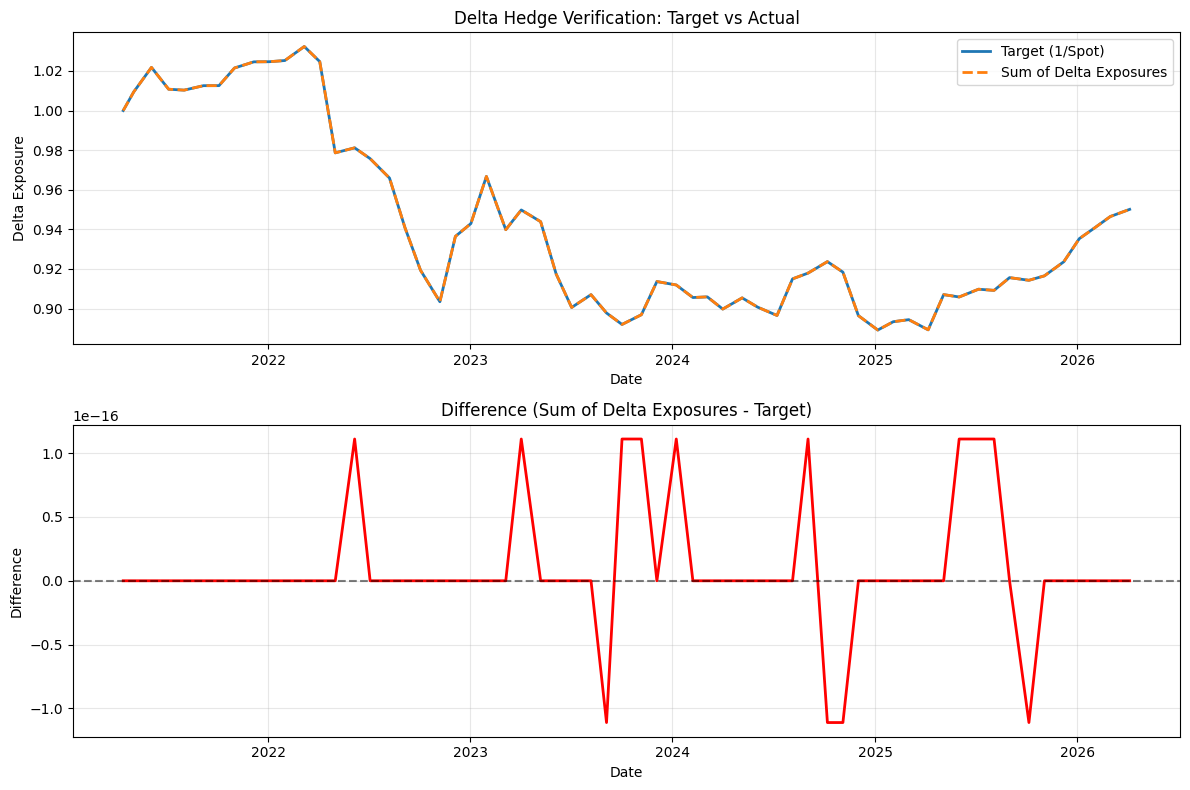

In [0]:
def verify_delta_hedge(option_df, spot_df, cutoff_date='2026-04-14'):
    """
    Verify that sum of delta exposures across all positions equals 1/spot.
    """
    
    # Get unique start and exit dates
    start_dates = set(option_df['Start_Date'].unique())
    exit_dates = set(option_df['Exit_Date'].unique())
    check_dates = sorted(start_dates | exit_dates)
    
    # Filter dates
    cutoff = pd.Timestamp(cutoff_date)
    check_dates = [d for d in check_dates if pd.Timestamp(d) <= cutoff]
    
    verification_rows = []

    # Get initial spot (first start date)
    first_start_date = option_df['Start_Date'].min()
    initial_spot = spot_df.loc[first_start_date, 'Spot']
    
    
    for date in check_dates:
        # Get active contracts AFTER this date's transitions
        # (started on or before, exit AFTER - not on)
        active_contracts = option_df[
            (option_df['Start_Date'] <= date) & 
            (option_df['Exit_Date'] > date)  # ✅ This is correct
        ]
        
        # For contracts STARTING on this date, use their INITIAL delta
        # (the delta at their start date, which is this date)
        total_delta_exposure = 0
        
        for position in active_contracts['Position'].unique():
            pos_contracts = active_contracts[active_contracts['Position'] == position]
            # Get the most recent contract for this position
            most_recent = pos_contracts.sort_values('Start_Date', ascending=False).iloc[0]
            
            # If this contract started today, use its initial delta
            if most_recent['Start_Date'] == date:
                delta_to_use = most_recent['Contract_Delta']
            else:
                # Use current delta (at this verification date)
                current_data = option_df[
                    (option_df['Position'] == position) &
                    (option_df['Start_Date'] == most_recent['Start_Date']) &
                    (option_df['Pricing_Date'] == date)
                ]
                if len(current_data) > 0:
                    delta_to_use = current_data.iloc[0]['Contract_Delta']
                else:
                    delta_to_use = most_recent['Contract_Delta']
            
            delta_exposure = most_recent['Notional'] * abs(delta_to_use)
            total_delta_exposure += delta_exposure
        
        # Get spot and target
        spot = spot_df.loc[date, 'Spot']
        target_exposure = initial_spot / spot
        
        # Calculate difference
        difference = total_delta_exposure - target_exposure
        
        # Determine event type
        is_start = date in start_dates
        is_exit = date in exit_dates
        event_type = []
        if is_start:
            event_type.append('Start')
        if is_exit:
            event_type.append('Exit')
        
        verification_rows.append({
            'Date': date,
            'Event_Type': ', '.join(event_type),
            'Spot': spot,
            'Target_Exposure_1/S': target_exposure,
            'Sum_of_Delta_Exposures': total_delta_exposure,
            'Difference': difference,
            'Match': abs(difference) < 1e-6
        })
    
    verification_df = pd.DataFrame(verification_rows)
    
    # Print summary
    print(f"\n=== Delta Hedge Verification (Start & Exit Dates) ===")
    print(f"Total dates checked: {len(verification_df)}")
    print(f"Dates matching (within tolerance): {verification_df['Match'].sum()}")
    print(f"Dates not matching: {(~verification_df['Match']).sum()}")
    
    if not verification_df['Match'].all():
        print(f"\nDates with mismatches:")
        mismatches = verification_df[~verification_df['Match']]
        for _, row in mismatches.iterrows():
            print(f"  {row['Date']} ({row['Event_Type']}): Difference = {row['Difference']:.8f}")
    
    return verification_df

# Verify
verification_df = verify_delta_hedge(rr45_dynamic_full_notional_df, spot_df)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Target vs Actual
ax1.plot(verification_df['Date'], verification_df['Target_Exposure_1/S'], 
         label='Target (1/Spot)', linewidth=2)
ax1.plot(verification_df['Date'], verification_df['Sum_of_Delta_Exposures'], 
         label='Sum of Delta Exposures', linewidth=2, linestyle='--')
ax1.set_xlabel('Date')
ax1.set_ylabel('Delta Exposure')
ax1.set_title('Delta Hedge Verification: Target vs Actual')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Difference
ax2.plot(verification_df['Date'], verification_df['Difference'], 
         color='red', linewidth=2)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Date')
ax2.set_ylabel('Difference')
ax2.set_title('Difference (Sum of Delta Exposures - Target)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

RISK REVERSAL DATA QUALITY CHECKS

1. SUMMARY STATISTICS
       Call_Strike    Call_Delta  ...   Put_Premium         Value
count  3860.000000  3.860000e+03  ...  3.860000e+03  3.860000e+03
mean      6.945384  4.650759e-01  ...  7.454118e-03  2.826381e-03
std       0.299583  2.673467e-01  ...  7.124541e-03  1.641814e-02
min       6.384350  1.196249e-08  ...  2.446283e-18 -6.688097e-02
25%       6.694106  2.672469e-01  ...  2.305045e-03 -6.219049e-03
50%       7.080130  4.465953e-01  ...  6.304897e-03  1.203465e-07
75%       7.181496  6.482204e-01  ...  1.024625e-02  8.571624e-03
max       7.351873  9.862357e-01  ...  6.688134e-02  7.812469e-02

[8 rows x 7 columns]

2. STRIKE SANITY CHECKS
Call strikes > Put strikes (expected): 3860 / 3860
Call strikes in reasonable range [5, 10]: 3860 / 3860
Put strikes in reasonable range [5, 10]: 3860 / 3860

3. DELTA SANITY CHECKS
Call delta in [0, 1]: 3860 / 3860
Put delta in [-1, 0]: 3860 / 3860

4. PREMIUM SANITY CHECKS
Call premium > 0: 3860 / 3

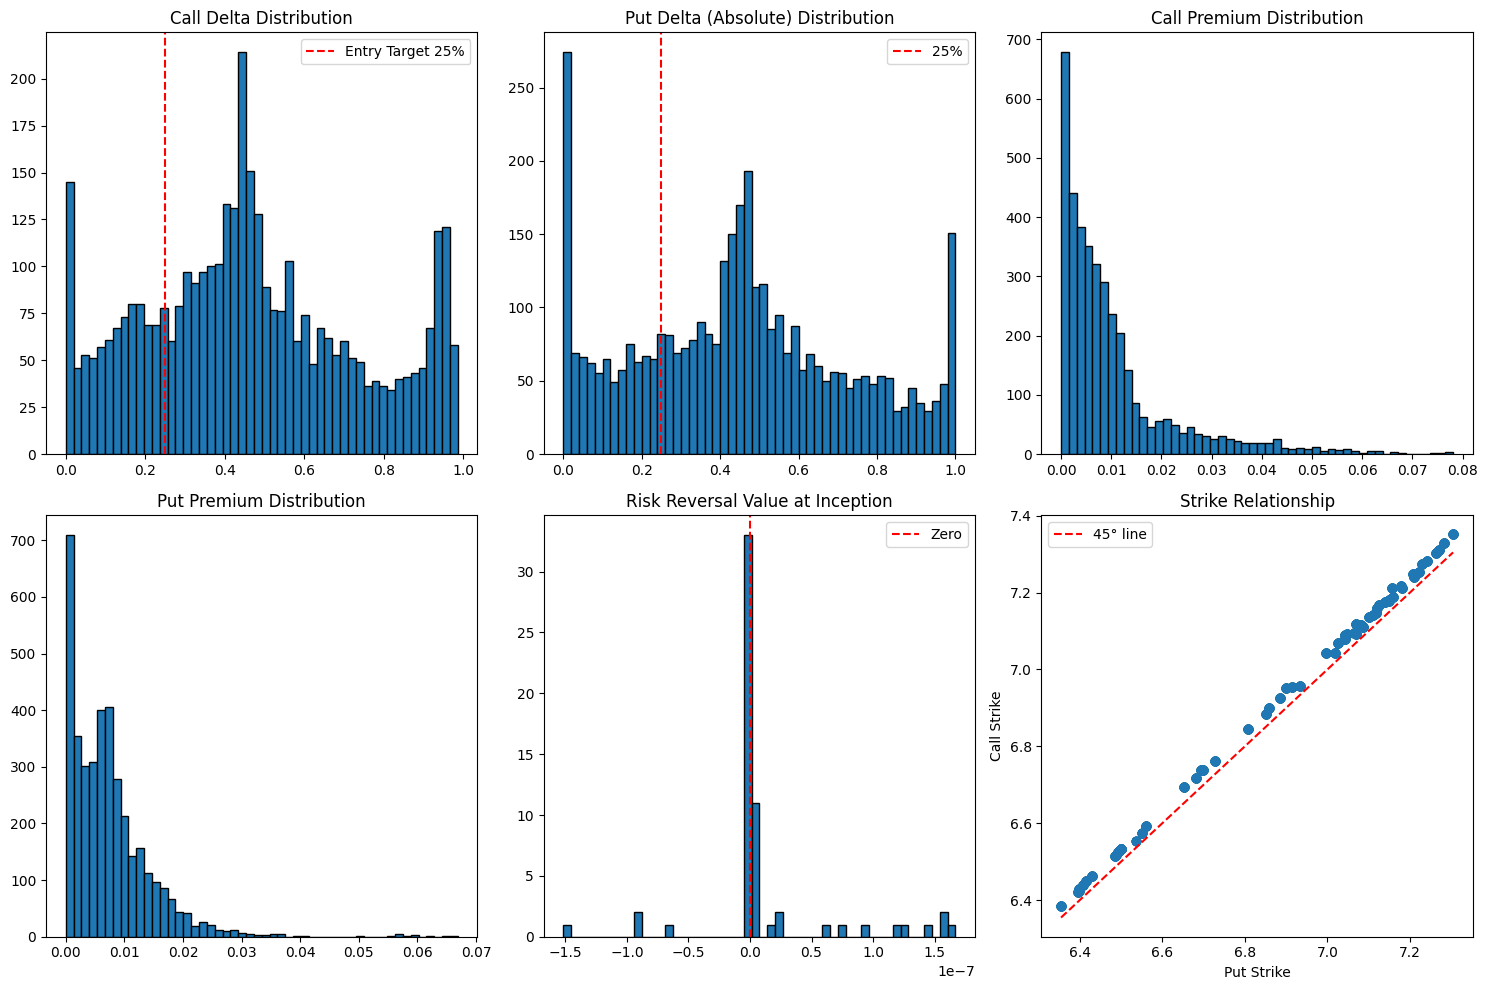

In [0]:
# Load data
df = pd.read_csv('risk_reversal_contracts_daily_values_45_delta_unit_notional.csv', parse_dates=['Pricing_Date', 'Start_Date', 'Settlement_Date', 'Expiry_Date', 'Delivery_Date', 'Exit_Date'])

print("=" * 60)
print("RISK REVERSAL DATA QUALITY CHECKS")
print("=" * 60)

# 1. BASIC STATISTICS
print("\n1. SUMMARY STATISTICS")
print(df[['Call_Strike', 'Call_Delta', 'Call_Premium', 'Put_Strike', 'Put_Delta', 'Put_Premium', 'Value']].describe())

# 2. STRIKE CHECKS
print("\n2. STRIKE SANITY CHECKS")
print(f"Call strikes > Put strikes (expected): {(df['Call_Strike'] > df['Put_Strike']).sum()} / {len(df)}")
print(f"Call strikes in reasonable range [5, 10]: {((df['Call_Strike'] >= 5) & (df['Call_Strike'] <= 10)).sum()} / {len(df)}")
print(f"Put strikes in reasonable range [5, 10]: {((df['Put_Strike'] >= 5) & (df['Put_Strike'] <= 10)).sum()} / {len(df)}")

# 3. DELTA CHECKS
print("\n3. DELTA SANITY CHECKS")
print(f"Call delta in [0, 1]: {((df['Call_Delta'] >= 0) & (df['Call_Delta'] <= 1)).sum()} / {len(df)}")
print(f"Put delta in [-1, 0]: {((df['Put_Delta'] >= -1) & (df['Put_Delta'] <= 0)).sum()} / {len(df)}")

# 4. PREMIUM CHECKS
print("\n4. PREMIUM SANITY CHECKS")
print(f"Call premium > 0: {(df['Call_Premium'] > 0).sum()} / {len(df)}")
print(f"Put premium > 0: {(df['Put_Premium'] > 0).sum()} / {len(df)}")
print(f"Premiums in reasonable range [0, 100000]: {((df['Call_Premium'] >= 0) & (df['Call_Premium'] <= 100000) & (df['Put_Premium'] >= 0) & (df['Put_Premium'] <= 100000)).sum()} / {len(df)}")

# 5. RISK REVERSAL VALUE CHECKS (INCEPTION ONLY)
print("\n5. RISK REVERSAL VALUE CHECKS (AT INCEPTION)")
df_inception = df[df['Pricing_Date'] == df['Start_Date']]
print(f"Value near zero at inception (|Value| < 1): {(df_inception['Value'].abs() < 1).sum()} / {len(df_inception)}")
print(f"Value range at inception: [{df_inception['Value'].min():.2f}, {df_inception['Value'].max():.2f}]")
print(f"Mean absolute value at inception: {df_inception['Value'].abs().mean():.2f}")

# 6. OUTLIER DETECTION (Z-score > 3)
print("\n6. OUTLIER DETECTION (|Z-score| > 3)")
from scipy import stats
for col in ['Call_Strike', 'Call_Delta', 'Call_Premium', 'Put_Strike', 'Put_Delta', 'Put_Premium', 'Value']:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers = (z_scores > 3).sum()
    print(f"{col}: {outliers} outliers")
    if outliers > 0:
        print(f"  Outlier values: {df[z_scores > 3][col].values[:5]}")  # Show first 5

# 9. IDENTIFY SPECIFIC OUTLIERS
print("\n9. SPECIFIC OUTLIER ROWS")
outlier_conditions = (
    (df['Call_Delta'] < 0.1) | (df['Call_Delta'] > 0.4) |
    (df['Put_Delta'].abs() < 0.1) | (df['Put_Delta'].abs() > 0.4) |
    (df['Value'].abs() > 1000) |
    (df['Call_Premium'] > 20000) | (df['Put_Premium'] > 20000)
)
outliers_df = df[outlier_conditions]
print(f"Found {len(outliers_df)} potential outlier rows")
if len(outliers_df) > 0:
    print(outliers_df[['Contract_ID', 'Pricing_Date', 'Call_Strike', 'Call_Delta', 'Call_Premium', 'Put_Strike', 'Put_Delta', 'Put_Premium', 'Value']].head(10))

# 10. VISUALIZATIONS
print("\n10. Generating diagnostic plots...")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Delta distributions
axes[0, 0].hist(df['Call_Delta'], bins=50, edgecolor='black')
axes[0, 0].set_title('Call Delta Distribution')
axes[0, 0].axvline(0.25, color='red', linestyle='--', label='Entry Target 25%')
axes[0, 0].legend()

axes[0, 1].hist(df['Put_Delta'].abs(), bins=50, edgecolor='black')
axes[0, 1].set_title('Put Delta (Absolute) Distribution')
axes[0, 1].axvline(0.25, color='red', linestyle='--', label='25%')
axes[0, 1].legend()

# Premium distributions
axes[0, 2].hist(df['Call_Premium'], bins=50, edgecolor='black')
axes[0, 2].set_title('Call Premium Distribution')

axes[1, 0].hist(df['Put_Premium'], bins=50, edgecolor='black')
axes[1, 0].set_title('Put Premium Distribution')

# Value distribution (inception only)
axes[1, 1].hist(df_inception['Value'], bins=50, edgecolor='black')
axes[1, 1].set_title('Risk Reversal Value at Inception')
axes[1, 1].axvline(0, color='red', linestyle='--', label='Zero')
axes[1, 1].legend()

# Strike relationship
axes[1, 2].scatter(df['Put_Strike'], df['Call_Strike'], alpha=0.5)
axes[1, 2].plot([df['Put_Strike'].min(), df['Put_Strike'].max()], 
                [df['Put_Strike'].min(), df['Put_Strike'].max()], 
                'r--', label='45° line')
axes[1, 2].set_xlabel('Put Strike')
axes[1, 2].set_ylabel('Call Strike')
axes[1, 2].set_title('Strike Relationship')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('risk_reversal_diagnostics_second_try.png', dpi=150)
print("Saved diagnostic plots to 'risk_reversal_diagnostics_second_try.png'")

print("\n" + "=" * 60)

In [0]:
# Create CSV of contracts to check based on quality criteria
df = pd.read_csv('risk_reversal_contracts_daily_values_second_try.csv', 
                 parse_dates=['Pricing_Date', 'Start_Date', 'Settlement_Date', 
                             'Expiry_Date', 'Delivery_Date', 'Exit_Date'])

# Initialize list to collect flagged rows
flagged_rows = []

# 1. Put delta not in [-1, 0]
invalid_put_delta = df[(df['Put_Delta'] < -1) | (df['Put_Delta'] > 0)].copy()
invalid_put_delta['Flag_Reason'] = 'Put_Delta_Out_Of_Range'
flagged_rows.append(invalid_put_delta)

# 2. Premiums not in reasonable range [0, 50000]
invalid_premiums = df[
    (df['Call_Premium'] < 0) | (df['Call_Premium'] > 50000) |
    (df['Put_Premium'] < 0) | (df['Put_Premium'] > 50000)
].copy()
invalid_premiums['Flag_Reason'] = 'Premium_Large'
flagged_rows.append(invalid_premiums)

# 3. Large daily premium jumps
df_sorted = df.sort_values(['Contract_ID', 'Pricing_Date'])
df_sorted['Call_Premium_Change'] = df_sorted.groupby('Contract_ID')['Call_Premium'].diff()
df_sorted['Put_Premium_Change'] = df_sorted.groupby('Contract_ID')['Put_Premium'].diff()

large_call_jumps = df_sorted[df_sorted['Call_Premium_Change'].abs() > 10000].copy()
large_call_jumps['Flag_Reason'] = 'Large_Call_Premium_Jump'
flagged_rows.append(large_call_jumps)

large_put_jumps = df_sorted[df_sorted['Put_Premium_Change'].abs() > 10000].copy()
large_put_jumps['Flag_Reason'] = 'Large_Put_Premium_Jump'
flagged_rows.append(large_put_jumps)

# 4. Value not near zero at inception (pricing_date = start_date)
inception_rows = df[df['Pricing_Date'] == df['Start_Date']].copy()
invalid_inception_value = inception_rows[inception_rows['Value'].abs() >= 1].copy()
invalid_inception_value['Flag_Reason'] = 'Inception_Value_Not_Zero'
flagged_rows.append(invalid_inception_value)

# Combine all flagged rows
contracts_to_check = pd.concat(flagged_rows, ignore_index=True)

# Add market data columns (spot, forward, SOFR)
def add_market_data(row):
    pricing_date = row['Pricing_Date']
    expiry_date = row['Expiry_Date']
    delivery_date = row['Delivery_Date']
    
    try:
        # Spot
        spot = spot_df.loc[pricing_date, 'Spot']
        
        # Forward
        pricing_to_delivery_days = (delivery_date - pricing_date).days
        forward = forward_df.loc[pricing_date][pricing_to_delivery_days - 1]
        
        # SOFR
        sofr = sofr_df.loc[(pricing_date, expiry_date), 'SOFR']
        
        return pd.Series({'Spot': spot, 'Forward': forward, 'SOFR': sofr})
    except:
        return pd.Series({'Spot': np.nan, 'Forward': np.nan, 'SOFR': np.nan})

# Apply market data lookup
market_data = contracts_to_check.apply(add_market_data, axis=1)
contracts_to_check = pd.concat([contracts_to_check, market_data], axis=1)

# Keep original columns plus market data plus flag reason
original_columns = ['Contract_ID', 'Position', 'Pricing_Date', 'Start_Date', 
                   'Settlement_Date', 'Expiry_Date', 'Delivery_Date', 'Exit_Date',
                   'Call_Strike', 'Call_Delta', 'Call_Premium', 
                   'Put_Strike', 'Put_Delta', 'Put_Premium', 'Value']

contracts_to_check = contracts_to_check[original_columns + ['Spot', 'Forward', 'SOFR', 'Flag_Reason']]

# Sort by contract and date
contracts_to_check = contracts_to_check.sort_values(['Contract_ID', 'Pricing_Date'])

# Save to CSV
contracts_to_check.to_csv('contracts_to_check.csv', index=False)

# Print summary
print("=" * 60)
print("CONTRACTS TO CHECK - SUMMARY")
print("=" * 60)
print(f"Total flagged rows: {len(contracts_to_check)}")
print(f"\nBreakdown by flag reason:")
print(contracts_to_check['Flag_Reason'].value_counts())
print(f"\nUnique contracts affected: {contracts_to_check['Contract_ID'].nunique()}")
print(f"\nSaved to: contracts_to_check.csv")
print("=" * 60)

### First try (25d): in the money puts are wrong delta -> changed to unadjusted delta

In [0]:
# Findings
# All 'put delta out of range' are from in the money puts  -----> MADE PUT DELTAS < -1 TO BE CHANGED TO UNADJUSTED
# example: contract 8

# Contract 8 - Put Delta Verification for Multiple Dates
dates_to_check = [
    '2023-01-11', '2023-01-12', '2023-01-13', '2023-01-16', '2023-01-17',
    '2023-01-18', '2023-01-19', '2023-01-20', '2023-01-23', '2023-01-24',
    '2023-01-25', '2023-01-26', '2023-01-27', '2023-01-30'
]

print("=" * 90)
print("CONTRACT 8 - PUT DELTA VERIFICATION")
print("=" * 90)
print(f"{'Date':<12} {'Stored Δ':>12} {'Calculated Δ':>12} {'Vol (iter -ve)':>12} {'Vol (direct)':>12} {'Match':>8}")
print("-" * 90)

for date_str in dates_to_check:
    target_date = pd.to_datetime(date_str)
    row_data = contracts_to_check[
        (contracts_to_check['Contract_ID'] == 8) & 
        (contracts_to_check['Pricing_Date'] == target_date)
    ]
    
    if len(row_data) == 0:
        print(f"{date_str:<12} {'N/A':>12} {'N/A':>12} {'N/A':>12} {'N/A':>12} {'N/A':>8}")
        continue
    
    row = row_data.iloc[0]
    
    # Calculate put delta
    pricing_settlement_date = get_T2_lag_date(row['Pricing_Date'])
    trade_to_expiry_days = (row['Expiry_Date'] - row['Pricing_Date']).days
    settlement_to_delivery_days = (row['Delivery_Date'] - pricing_settlement_date).days
    
    # Get volatility using strike_to_volatility (iterative method)
    put_vol_iter = strike_to_volatility(row['Spot'], row['Pricing_Date'], pricing_settlement_date,
                                        row['Expiry_Date'], row['Delivery_Date'], row['Put_Strike'],
                                        row['SOFR'], row['Forward'], 'P', vol_bsplines_df, vol_date_tenor_df)
    
    # Get volatility directly from surface using stored delta
    put_vol_direct = get_volatility_from_bsplines(row['Pricing_Date'], trade_to_expiry_days,
                                                   abs(row['Put_Delta']), 'P', 
                                                   vol_bsplines_df, vol_date_tenor_df)
    
    # Price put option
    put_result = price_fx_option(row['Spot'], trade_to_expiry_days, settlement_to_delivery_days,
                                 row['Put_Strike'], row['SOFR'], row['Forward'], put_vol_iter,
                                 'P', notional_ccy, premium_ccy)
    
    put_delta_calc = put_result[4]
    put_delta_stored = row['Put_Delta']
    match = "✓" if abs(put_delta_calc - put_delta_stored) < 0.0001 else "✗"
    
    print(f"{date_str:<12} {put_delta_stored:>12.6f} {put_delta_calc:>12.6f} {put_vol_iter:>12.6f} {put_vol_direct:>12.6f} {match:>8}")

print("=" * 90)

### Second try (25d): large premiums and large call premium jumps -> cross checked with OVML and they were correct

In [0]:
# ============================================================
# CONTRACTS TO CHECK - SUMMARY
# ============================================================
# Total flagged rows: 19

# Breakdown by flag reason:
# Large_Call_Premium_Jump    10
# Premium_Large               9
# Name: Flag_Reason, dtype: int64

# Unique contracts affected: 5

# Saved to: contracts_to_check.csv
# ============================================================